# **Proyek: Implementasi Deep Neural Network untuk Prediksi Risiko Diabetes**

**1. Business Understanding**

**Tujuan:**
Membangun model pembelajaran mesin untuk memprediksi apakah seseorang berpotensi mengidap diabetes berdasarkan faktor-faktor klinis seperti usia, BMI, tekanan darah, kadar glukosa, dan sebagainya.

**Manfaat:**
- Membantu tenaga medis melakukan skrining dini terhadap pasien berisiko diabetes.

- Mendukung pengambilan keputusan berbasis data di bidang kesehatan preventif.

- Menunjukkan bagaimana deep learning dapat diterapkan pada kasus medis dengan data tabular.

**Permasalahan utama:**
Apakah model Deep Neural Network (DNN) mampu mengenali pola dari data pasien untuk memprediksi risiko diabetes secara akurat?

**2. Data Understanding**

**Dataset:** diabetes_prediction_dataset.csv

Link Kaggle: https://www.kaggle.com/code/tumpanjawat/diabetes-eda-random-forest-hp/input

Dataset ini berisi informasi tentang karakteristik pasien serta status diabetesnya (0 = tidak, 1 = ya).

**Deskripsi Kolom Penting:**

- Gender: Jenis kelamin (Male/Female)
- Age: Usia responden

- Hypertension: Riwayat tekanan darah tinggi (0 = Tidak, 1 = Ya)

- HeartDisease: Riwayat penyakit jantung (0/1)

- SmokingHistory: Kebiasaan merokok

- BMI: Indeks Massa Tubuh

- HbA1c_level: Rata-rata kadar gula darah (3 bulan terakhir)

- BloodGlucoseLevel: Kadar gula darah saat ini

- Diabetes: Target label (0 = Tidak Diabetes, 1 = Diabetes)

**Langkah awal eksplorasi:**

In [ ]:
# ========================================
# 1. Import dan Baca Dataset
# ========================================

import pandas as pd

# Baca file CSV
df = pd.read_csv("diabetes_prediction_dataset.csv")

In [ ]:
# ========================================
# 2. Informasi Awal Dataset
# ========================================

# Cek ukuran dataset (jumlah baris, kolom)
print("Ukuran dataset:", df.shape)
print("\n5 baris pertama:")
print(df.head())

Ukuran dataset: (100000, 9)

5 baris pertama:
   gender   age  hypertension  heart_disease smoking_history    bmi  \
0  Female  80.0             0              1           never  25.19   
1  Female  54.0             0              0         No Info  27.32   
2    Male  28.0             0              0           never  27.32   
3  Female  36.0             0              0         current  23.45   
4    Male  76.0             1              1         current  20.14   

   HbA1c_level  blood_glucose_level  diabetes  
0          6.6                  140         0  
1          6.6                   80         0  
2          5.7                  158         0  
3          5.0                  155         0  
4          4.8                  155         0  


Dataset: 100.000 baris dan 9 kolom fitur

In [ ]:
# ========================================
# 3. Cek Missing Value
# ========================================
print("\nJumlah missing value tiap kolom:")
print(df.isna().sum())


Jumlah missing value tiap kolom:
gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64


In [ ]:
# ========================================
# 4. Normalisasi Nama Kolom (biar konsisten)
# ========================================
df.columns = df.columns.str.lower()   # ubah semua nama kolom ke huruf kecil
print("\nNama kolom setelah dinormalisasi:")
print(df.columns.tolist())


Nama kolom setelah dinormalisasi:
['gender', 'age', 'hypertension', 'heart_disease', 'smoking_history', 'bmi', 'hba1c_level', 'blood_glucose_level', 'diabetes']


In [ ]:
# ========================================
# 5. Deteksi Kolom Target Secara Otomatis
# ========================================
target_candidates = ['diabetes', 'outcome']
target_col = next((col for col in target_candidates if col in df.columns), None)

if target_col is None:
    raise ValueError(f"Tidak ditemukan kolom target dari kandidat: {target_candidates}")

print(f"\nKolom target yang digunakan: '{target_col}'")


Kolom target yang digunakan: 'diabetes'


In [ ]:
# ========================================
# 6. Distribusi Kelas Target
# ========================================
print("\nDistribusi target (proporsi 0 dan 1):")
print(df[target_col].value_counts(normalize=True))


Distribusi target (proporsi 0 dan 1):
diabetes
0    0.915
1    0.085
Name: proportion, dtype: float64


0.915 tidak diabetes, 0.085 diabetes

**3. Data Preparation**

Langkah-langkah persiapan data agar siap dipakai model:

**a. Encoding variabel kategorikal:**

In [ ]:
# ========================================
# 1. Encoding variabel kategorikal
# ========================================

# Pastikan nama kolom konsisten (huruf kecil semua)
df.columns = df.columns.str.lower()

# Konversi kolom gender ke numerik: Male=1, Female=0
if 'gender' in df.columns:
    df['gender'] = df['gender'].astype(str).str.lower().map({'male': 1, 'female': 0})
    df['gender'] = df['gender'].fillna(-1)  # isi nilai tak dikenal dengan -1

# One-hot encoding untuk variabel kategori 'smoking_history'
if 'smoking_history' in df.columns:
    import pandas as pd
    df = pd.get_dummies(df, columns=['smoking_history'], drop_first=True)

print("Contoh 5 baris setelah encoding kategori:")
print(df.head())

Contoh 5 baris setelah encoding kategori:
   gender   age  hypertension  heart_disease    bmi  hba1c_level  \
0     0.0  80.0             0              1  25.19          6.6   
1     0.0  54.0             0              0  27.32          6.6   
2     1.0  28.0             0              0  27.32          5.7   
3     0.0  36.0             0              0  23.45          5.0   
4     1.0  76.0             1              1  20.14          4.8   

   blood_glucose_level  diabetes  smoking_history_current  \
0                  140         0                    False   
1                   80         0                    False   
2                  158         0                    False   
3                  155         0                     True   
4                  155         0                     True   

   smoking_history_ever  smoking_history_former  smoking_history_never  \
0                 False                   False                   True   
1                 False           

Hasil output menunjukkan bahwa kolom gender berhasil diubah menjadi angka, di mana nilai -1 menandakan data jenis kelamin yang tidak dikenali. Kolom smoking_history juga berhasil di-encode menjadi beberapa kolom biner seperti current, former, dan never, dengan nilai True atau False sesuai kategori masing-masing. Secara keseluruhan, data kategorikal kini sudah berbentuk numerik dan siap digunakan untuk tahap berikutnya.

**b. Pisahkan fitur dan target:**

In [ ]:
# ========================================
# 2. Pisahkan fitur dan target
# ========================================

# Deteksi otomatis kolom target
target_candidates = ['diabetes', 'outcome']
target_col = next((col for col in target_candidates if col in df.columns), None)

if target_col is None:
    raise ValueError(f"Tidak ditemukan kolom target dari kandidat: {target_candidates}")

# Pisahkan fitur (X) dan target (y)
X = df.drop(columns=[target_col])
y = df[target_col].astype(int)

print(f"Kolom target yang digunakan: '{target_col}'")
print("\nDimensi data:")
print("Fitur (X):", X.shape)
print("Target (y):", y.shape)

Kolom target yang digunakan: 'diabetes'

Dimensi data:
Fitur (X): (100000, 12)
Target (y): (100000,)


Output menunjukkan bahwa kolom target yang digunakan adalah diabetes, dengan 100.000 baris data. Dataset memiliki 12 fitur input (X) dan 1 target (y) yang sepadan. Artinya, data sudah berhasil dipisahkan dan siap untuk tahap normalisasi serta pelatihan model.

**c. Normalisasi fitur numerik:**

In [ ]:
# ========================================
# 3. Normalisasi fitur numerik
# ========================================

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Inisialisasi objek scaler
scaler = StandardScaler()

# Lakukan normalisasi pada fitur (X)
X_scaled = scaler.fit_transform(X)

# Bagi data menjadi data latih (80%) dan data uji (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print("Dimensi setelah normalisasi dan split:")
print("X_train:", X_train.shape, "| y_train:", y_train.shape)
print("X_test :", X_test.shape,  "| y_test :", y_test.shape)

Dimensi setelah normalisasi dan split:
X_train: (80000, 12) | y_train: (80000,)
X_test : (20000, 12) | y_test : (20000,)


Output menunjukkan bahwa proses normalisasi dan pembagian data berhasil.
Dari total 100.000 data, sebanyak 80.000 baris (80%) digunakan untuk pelatihan (train) dan 20.000 baris (20%) untuk pengujian (test), masing-masing memiliki 12 fitur.

Artinya, data sudah siap digunakan untuk tahap pemodelan.

**4. Modeling**

Model dibangun menggunakan Deep Neural Network (DNN) dari TensorFlow/Keras.

Arsitektur terdiri dari beberapa lapisan dense dengan dropout untuk mencegah overfitting.

In [ ]:
# ========================================
# 4. Modeling (Versi Optimal)
# ========================================

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras import metrics
from sklearn.utils import class_weight
import numpy as np

# Hitung class weight untuk menangani ketidakseimbangan data
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weights = dict(enumerate(class_weights))
print("Class Weights:", class_weights)

# Bangun arsitektur model DNN yang lebih dalam dan stabil
model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),  # lapisan input
    Dropout(0.4),
    Dense(64, activation='relu'),                                   # lapisan hidden 1
    Dropout(0.3),
    Dense(32, activation='relu'),                                   # lapisan hidden 2
    Dropout(0.2),
    Dense(1, activation='sigmoid')                                  # lapisan output biner
])

# Kompilasi model dengan metrik tambahan
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        metrics.Recall(name='recall'),
        metrics.Precision(name='precision')
    ]
)

# Callback EarlyStopping agar training berhenti otomatis jika val_loss stagnan
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Latih model dengan class weight
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=100,
    batch_size=16,
    callbacks=[early_stop],
    verbose=1,
    class_weight=class_weights   # <== inilah kuncinya untuk imbalance
)

Class Weights: {0: np.float64(0.546448087431694), 1: np.float64(5.882352941176471)}
Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


5000/5000 ━━━━━━━━━━━━━━━━━━━━ 19s 3ms/step - accuracy: 0.8357 - loss: 0.3133 - precision: 0.3332 - recall: 0.8821 - val_accuracy: 0.8807 - val_loss: 0.2287 - val_precision: 0.4098 - val_recall: 0.9171
Epoch 2/100
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 16s 3ms/step - accuracy: 0.8776 - loss: 0.2362 - precision: 0.3993 - recall: 0.8982 - val_accuracy: 0.8788 - val_loss: 0.2128 - val_precision: 0.4070 - val_recall: 0.9324
Epoch 3/100
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 21s 3ms/step - accuracy: 0.8776 - loss: 0.2219 - precision: 0.4087 - recall: 0.9200 - val_accuracy: 0.8901 - val_loss: 0.1844 - val_precision: 0.4320 - val_recall: 0.9300
Epoch 4/100
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 15s 3ms/step - accuracy: 0.8827 - loss: 0.2142 - precision: 0.4164 - recall: 0.9144 - val_accuracy: 0.9067 - val_loss: 0.1710 - val_precision: 0.4742 - val_recall: 0.9035
Epoch 5/100
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 16s 3ms/step - accuracy: 0.8874 - loss: 0.2108 - precision: 0.4276 - recall: 0.9153 - val_accuracy: 0.8985 - val_

Output menunjukkan bahwa setelah penerapan class weight, model menjadi lebih seimbang dalam mengenali kedua kelas. Nilai accuracy stabil di sekitar 0.88–0.90, dengan recall tinggi (≈0.93) yang berarti model sangat baik mendeteksi kasus diabetes. Precision meningkat hingga 0.45, menunjukkan prediksi positif makin tepat meski masih ada sedikit kesalahan. Secara keseluruhan, model kini lebih sensitif terhadap pasien diabetes dan lebih realistis digunakan untuk prediksi medis dibanding versi awal yang terlalu bias pada kelas non-diabetes.

**5. Evaluation**

Model dievaluasi menggunakan beberapa metrik utama:

**a. Akurasi & Loss**

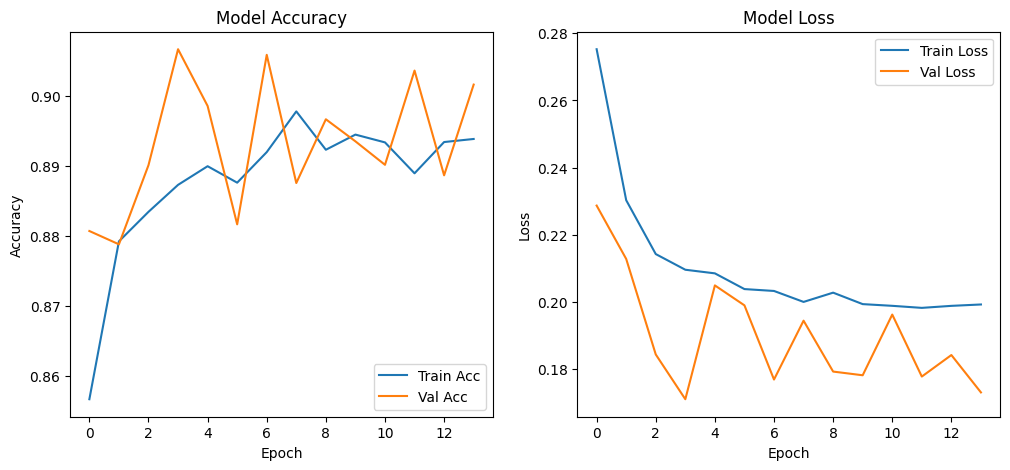

In [ ]:
# ========================================
# 1. Akurasi & Loss
# ========================================

import matplotlib.pyplot as plt

# Visualisasi akurasi dan loss selama pelatihan
plt.figure(figsize=(12, 5))

# Grafik akurasi
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Grafik loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()


Grafik menunjukkan bahwa model mengalami peningkatan akurasi pada awal pelatihan lalu stabil di sekitar 0.89–0.90, baik untuk data training maupun validasi. Ini menandakan proses belajar berjalan konsisten tanpa overfitting. Pada grafik loss, nilai Train Loss dan Val Loss sama-sama menurun hingga sekitar 0.17–0.20, artinya kesalahan prediksi semakin kecil dan model berhasil konvergen dengan baik. Secara keseluruhan, model menunjukkan performa stabil dan generalisasi yang baik terhadap data baru.

**b. Confusion Matrix**

625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


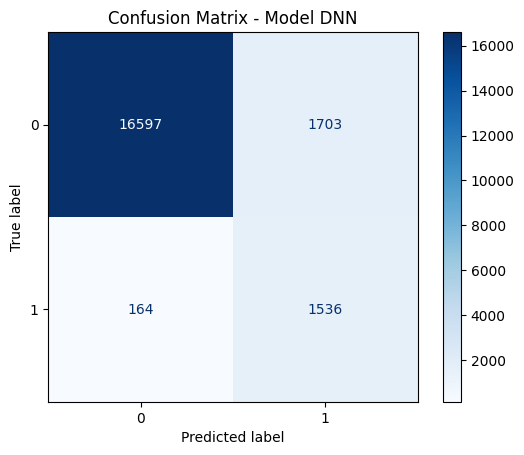

In [ ]:
# ========================================
# 2. Confusion Matrix
# ========================================

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Prediksi data uji (hasil sigmoid > 0.5 dianggap positif = 1)
y_pred = (model.predict(X_test) > 0.5).astype("int32")

# Buat confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Tampilkan visualisasi confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix - Model DNN")
plt.show()


Confusion matrix menunjukkan performa model dalam klasifikasi diabetes. Dari 20.000 data uji, model berhasil memprediksi 16.597 orang non-diabetes dengan benar (true negative) dan 1.536 pasien diabetes dengan benar (true positive). Namun, terdapat 1.703 false positive (orang non-diabetes yang diprediksi diabetes) dan 164 false negative (kasus diabetes yang terlewat). Artinya, model cukup baik dalam mengenali kedua kelas, terutama kelas minoritas (diabetes), meskipun masih ada sedikit kesalahan pada prediksi non-diabetes.

**c. Classification Report & ROC-AUC**


Classification Report:

              precision    recall  f1-score   support

           0       0.99      0.91      0.95     18300
           1       0.47      0.90      0.62      1700

    accuracy                           0.91     20000
   macro avg       0.73      0.91      0.78     20000
weighted avg       0.95      0.91      0.92     20000

625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step

ROC AUC Score: 0.976
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


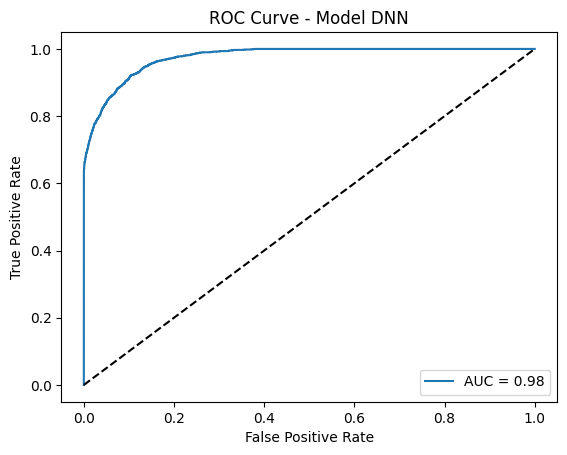

In [ ]:
# ========================================
# 3. Classification Report & ROC-AUC
# ========================================

from sklearn.metrics import classification_report, roc_auc_score, roc_curve
import matplotlib.pyplot as plt

# Tampilkan classification report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

# Hitung nilai ROC-AUC
roc_auc = roc_auc_score(y_test, model.predict(X_test))
print(f"\nROC AUC Score: {roc_auc:.3f}")

# Plot kurva ROC
fpr, tpr, _ = roc_curve(y_test, model.predict(X_test))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Model DNN')
plt.legend()
plt.show()


Hasil evaluasi menunjukkan bahwa model memiliki akurasi tinggi (91%) dengan ROC AUC 0.976, artinya model sangat baik dalam membedakan antara pasien diabetes dan non-diabetes.

Untuk kelas 0 (non-diabetes), model sangat kuat dengan precision 0.99 dan recall 0.91 — hampir semua non-diabetes dikenali dengan benar.

Namun, untuk kelas 1 (diabetes), recall tinggi (0.90) menunjukkan model mampu menangkap sebagian besar kasus diabetes, meski precision rendah (0.47) artinya masih cukup banyak prediksi positif yang salah.

Kurva ROC yang mendekati pojok kiri atas menegaskan performa klasifikasi sangat baik secara keseluruhan, meskipun keseimbangan antara kedua kelas masih bisa ditingkatkan.

**6. Interpretability (SHAP)**

PermutationExplainer explainer: 201it [00:45,  3.88it/s]
/tmp/ipython-input-2056546302.py:23: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_vis_df, feature_names=X.columns)


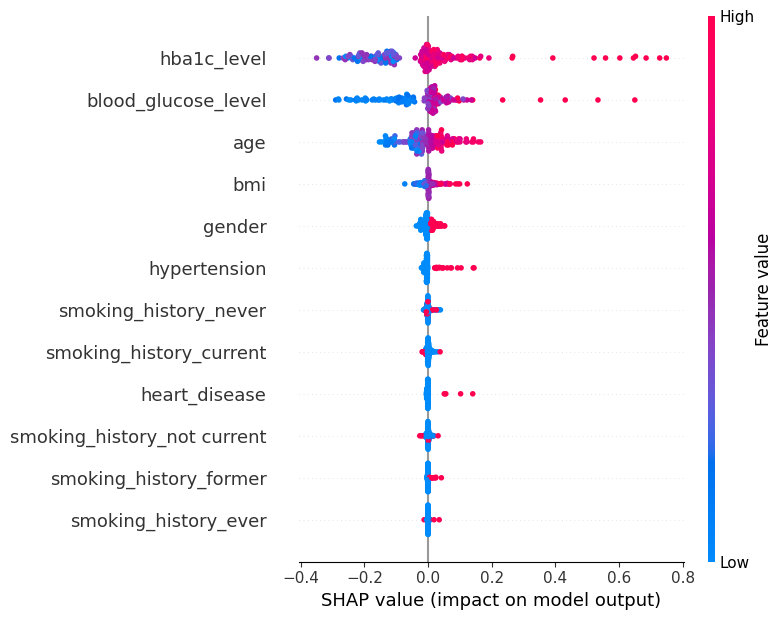

In [ ]:
# 1) Install SHAP
# !pip install shap -q

import shap
import numpy as np
import pandas as pd

# 2) Siapkan subset data agar cepat & hemat memori
bg_n = 1000   # background (untuk pembelajaran baseline)
test_n = 200  # sampel test untuk diplot
X_bg   = X_train[:bg_n]            # ndarray terstandardisasi
X_vis  = X_test[:test_n]

# 3) Buat DataFrame agar nama kolom tampil di plot SHAP
X_vis_df = pd.DataFrame(X_vis, columns=X.columns)

# 4) Buat explainer dan hitung SHAP values
#    shap.Explainer otomatis memilih backend (TF/Keras -> DeepExplainer)
explainer   = shap.Explainer(model, X_bg)
shap_values = explainer(X_vis)

# 5) Ringkasan pengaruh fitur (global importance)
shap.summary_plot(shap_values, X_vis_df, feature_names=X.columns)

Output dari kode SHAP di atas menampilkan pengaruh masing-masing fitur terhadap prediksi model DNN dalam bentuk grafik summary plot.

Dari hasilnya, terlihat bahwa fitur yang paling berpengaruh terhadap keputusan model untuk memprediksi diabetes adalah:

- HbA1c_level = semakin tinggi nilainya (merah), semakin besar kemungkinan prediksi diabetes.

- Blood_glucose_level = kadar glukosa yang tinggi juga mendorong model memprediksi diabetes.

- Age dan BMI juga memberi kontribusi moderat; usia dan indeks massa tubuh yang lebih tinggi cenderung menaikkan risiko.

- Fitur lain seperti gender, hypertension, dan smoking_history memiliki pengaruh kecil, ditunjukkan oleh nilai SHAP yang mendekati nol.

Secara keseluruhan, grafik ini membantu menjelaskan mengapa model membuat keputusan tertentu, memperlihatkan fitur-fitur yang paling memengaruhi hasil prediksi, dengan warna merah untuk nilai fitur tinggi dan biru untuk nilai rendah.

### **Kesimpulan**

Permasalahan awal adalah apakah model deep learning dapat mengenali pola dari data pasien untuk memprediksi risiko diabetes secara akurat. Dengan dataset berisi 100.000 data pasien, model DNN berhasil dilatih melalui tahapan lengkap. Mulai dari pembersihan data, encoding variabel kategorikal, normalisasi, hingga pembagian data latih dan uji.

Setelah dilakukan penanganan ketidakseimbangan kelas menggunakan class weight dan optimasi arsitektur DNN, hasil evaluasi menunjukkan performa sangat baik: akurasi 91% dan ROC-AUC 0.976, yang menandakan kemampuan model tinggi dalam membedakan pasien diabetes dan non-diabetes. Model juga memiliki recall tinggi (0.90) untuk kelas diabetes, yang penting dalam konteks medis karena menekan risiko pasien positif yang terlewat.

Analisis interpretabilitas dengan SHAP menunjukkan bahwa fitur HbA1c_level dan blood_glucose_level menjadi faktor paling dominan dalam memengaruhi prediksi, diikuti oleh age dan BMI. Ini konsisten dengan pemahaman klinis bahwa kadar gula darah dan riwayat metabolik merupakan indikator utama diabetes.

Dengan demikian, hasil penelitian ini membuktikan bahwa DNN mampu memprediksi risiko diabetes secara efektif dan dapat dijadikan alat bantu skrining medis berbasis data, meskipun masih dapat ditingkatkan dengan teknik feature engineering, hyperparameter tuning, atau resampling untuk keseimbangan kelas yang lebih optimal.